<a href="https://colab.research.google.com/github/Lightrex7749/AI-ML-DL/blob/main/pretrained_practical_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
#Global imports for deeo learning vvisualization and metrics
import os
import sys
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,Subset
from torchvision import datasets, models, transforms
import torchvision

from sklearn.metrics import classification_report,confusion_matrix
from sklearn.decomposition import PCA

#set deterministic seeds from 100% reporoductive results
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic=True

#device configration

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("=" * 65)
print(f"PyTorch version:  {torch.__version__}")
print(f"torchvision ver :{torchvision.__version__}")
print(f"computation device: {device}")

if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available")
print("=" * 65)

#plot stylinf asthetic



PyTorch version:  2.11.0+cu128
torchvision ver :0.26.0+cu128
computation device: cuda
GPU name: Tesla T4


In [13]:
#classroom Speed Confogration
FAST_DEMO=True
BATCH_SIZE=64
MIM_CLASSES=10
IMAGE_SIZE=224

train_transforms=transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tranformers=transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [15]:
import torchvision
from torchvision import transforms # Added for transforms

#classroom Speed Confogration
FAST_DEMO=True
BATCH_SIZE=64
MIM_CLASSES=10
IMAGE_SIZE=224

train_transforms=transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tranformers=transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])



In [16]:
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import kagglehub # Added for Kaggle dataset download

# --- Start: Data Loading from Kagglehub ---
print('Downloading and loading CIFAR-10 dataset from Kagglehub...')
kaggle_dataset_path = kagglehub.dataset_download("pankrzysiu/cifar10-python")
print(f"Kaggle Dataset downloaded and extracted to: {kaggle_dataset_path}")

# Load the dataset using torchvision.datasets.CIFAR10, pointing to the Kagglehub path
# Assuming 'cifar-10-batches-py' is directly within kaggle_dataset_path
full_train_dataset=datasets.CIFAR10(root=kaggle_dataset_path,train=True,download=False,transform=train_transforms)
full_test_dataset=datasets.CIFAR10(root=kaggle_dataset_path,train=False,download=False,transform=val_tranformers)
# --- End: Data Loading from Kagglehub ---

class_names=full_train_dataset.classes
print(f'Dataset loaded! Target Classes ({len(class_names)}): {class_names}')
# 3. Subsetting for rapid classroom demonstration if FAST_DEMO = True
if FAST_DEMO:
  train_subset_indices=list(range(5000))
  test_subset_indices=list(range(1000))
  train_dataset=Subset(full_train_dataset,train_subset_indices)
  test_dataset=Subset(full_test_dataset,test_subset_indices)
  print(f' FAST_DEMO active: Using {len(train_dataset)} training samples & {len(test_dataset)} test samples')
else:
  train_dataset=full_train_dataset
  test_dataset=full_test_dataset
  print(f' Full Dataset active: {len(train_dataset)} training samples & {len(test_dataset)} test samples')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Using Colab cache for faster access to the 'cifar10-python' dataset.
Kaggle Dataset downloaded and extracted to: /kaggle/input/cifar10-python
Dataset loaded! Target Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
 FAST_DEMO active: Using 5000 training samples & 1000 test samples


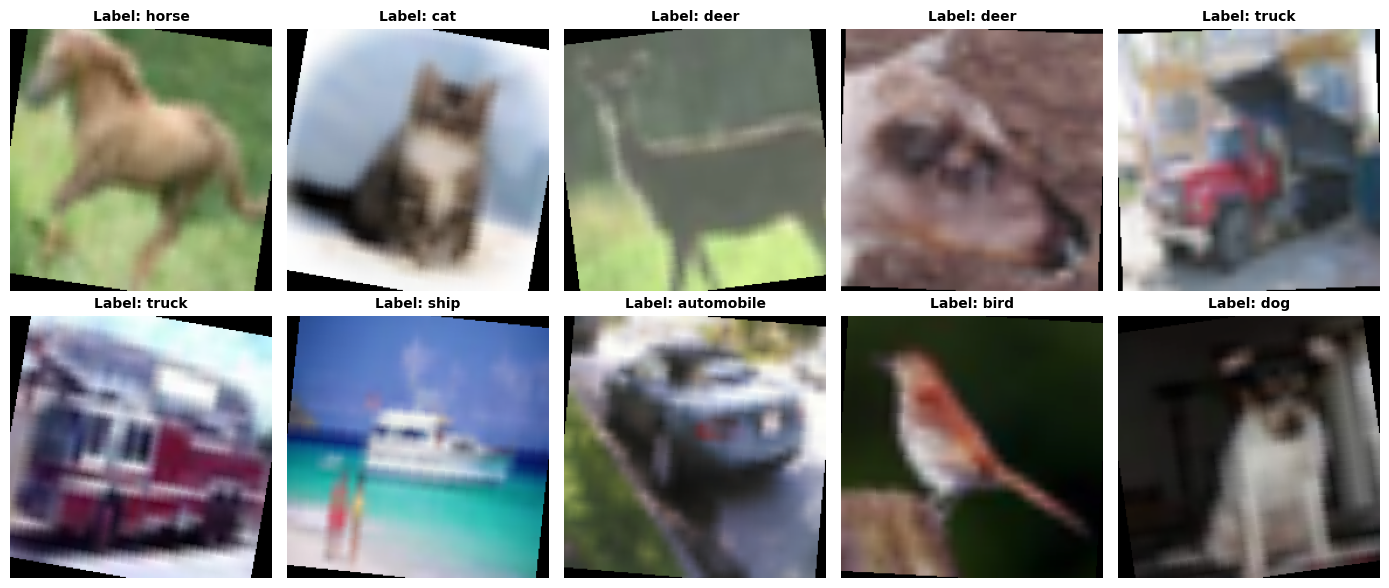

In [19]:
#2 Visializing CIFAR-10
def denormalizer(tensor):
  # Corrected mean and std arrays to match transforms.Normalize and have 3 elements
  mean=np.array([0.485, 0.456, 0.406])
  std=np.array([0.229, 0.224, 0.225])
  img=tensor.cpu().permute(1,2,0).numpy()
  img=std * img + mean
  return np.clip(img,0,1)

#visualize

fig,axes=plt.subplots(2,5,figsize=(14,6))
axes=axes.flatten()

sample_image,sample_labels=next(iter(train_loader))
for i in range(10):
  ax=axes[i]
  ax.imshow(denormalizer(sample_image[i]))
  ax.set_title(f'Label: {class_names[sample_labels[i]]}', fontsize = 10, fontweight = 'bold')
  ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
# 1. Instantiate pretrained ResNet-18 with ImageNet weights
print('📥 Loading Pretrained ResNet-18 model from torchvision...')
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Count initial parameters
total_params_orig = sum(p.numel() for p in model.parameters())
print(f'Total Original ResNet-18 Parameters: {total_params_orig:,}')

# 2. FREEZE ALL BACKBONE LAYERS
for param in model.parameters():
    param.requires_grad = False

# Verify freezing
trainable_params_after_freeze = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'🔒 Trainable Parameters After Freezing Backbone: {trainable_params_after_freeze}')
print('   -> The entire convolutional backbone is now locked in place!')

📥 Loading Pretrained ResNet-18 model from torchvision...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]

Total Original ResNet-18 Parameters: 11,689,512
🔒 Trainable Parameters After Freezing Backbone: 0
   -> The entire convolutional backbone is now locked in place!
